# Modelo de Fermi–Hubbard: dinámica de Trotter y régimen de Mott

El modelo de Fermi–Hubbard describe fermiones con espín que pueden saltar entre
sitios vecinos y que pagan una energía $U$ cuando dos partículas ocupan el
mismo sitio:


$$
H=-J\sum_{\langle i,j\rangle,\sigma}
(c^\dagger_{i\sigma}c_{j\sigma}+c^\dagger_{j\sigma}c_{i\sigma})
+U\sum_i n_{i\uparrow}n_{i\downarrow}.
$$

Usaremos $J$ para la amplitud de *hopping* y $\tau$ para el tiempo, evitando
la ambigüedad habitual de llamar $t$ a ambos. La competencia está gobernada
por $U/J$:

- $U/J\ll1$: las partículas se deslocalizan y la doble ocupación es accesible.
- $U/J\gg1$: la doble ocupación se suprime; a media ocupación aparece el
  régimen aislante de Mott con correlaciones antiferromagnéticas.

La dinámica se aproxima con Trotter de primer orden. Para diagnosticar el estado
fundamental usamos, además, diagonalización exacta en una cadena pequeña.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from Funciones_F_h import *

estilo_graficas()
np.set_printoptions(precision=4, suppress=True)

## 1. Condiciones iniciales

Trabajamos con $L=4$ sitios y media ocupación ($N=4$). Cada sitio se codifica
con dos qubits: $q_{2i}$ representa espín arriba y $q_{2i+1}$, espín abajo.

Comparamos tres estados producto:

1. **Néel:** un fermión por sitio con espines alternados.
2. **Onda de doublones:** sitios vacíos y doblemente ocupados alternados.
3. **Bloque localizado:** las partículas comienzan concentradas en la mitad izquierda.

No son estados fundamentales; permiten observar cómo $J$ y $U$ controlan el
transporte y la creación o destrucción de doble ocupación.

In [2]:
n_sites = 4
n_q = 2 * n_sites
J = 1.0
U = 4.0
tiempos = np.linspace(0, 5, 41)
r = 20

condiciones = {
    "Néel": [0, 3, 4, 7],
    "Onda de doublones": [0, 1, 4, 5],
    "Bloque localizado": [0, 1, 2, 3],
}

resultados_iniciales = {}
for nombre, ocupados in condiciones.items():
    resultados_iniciales[nombre] = evolucion_FH(
        hop=J, U=U, n_q=n_q, r=r,
        tiempos=tiempos, occupied_modes=ocupados
    )

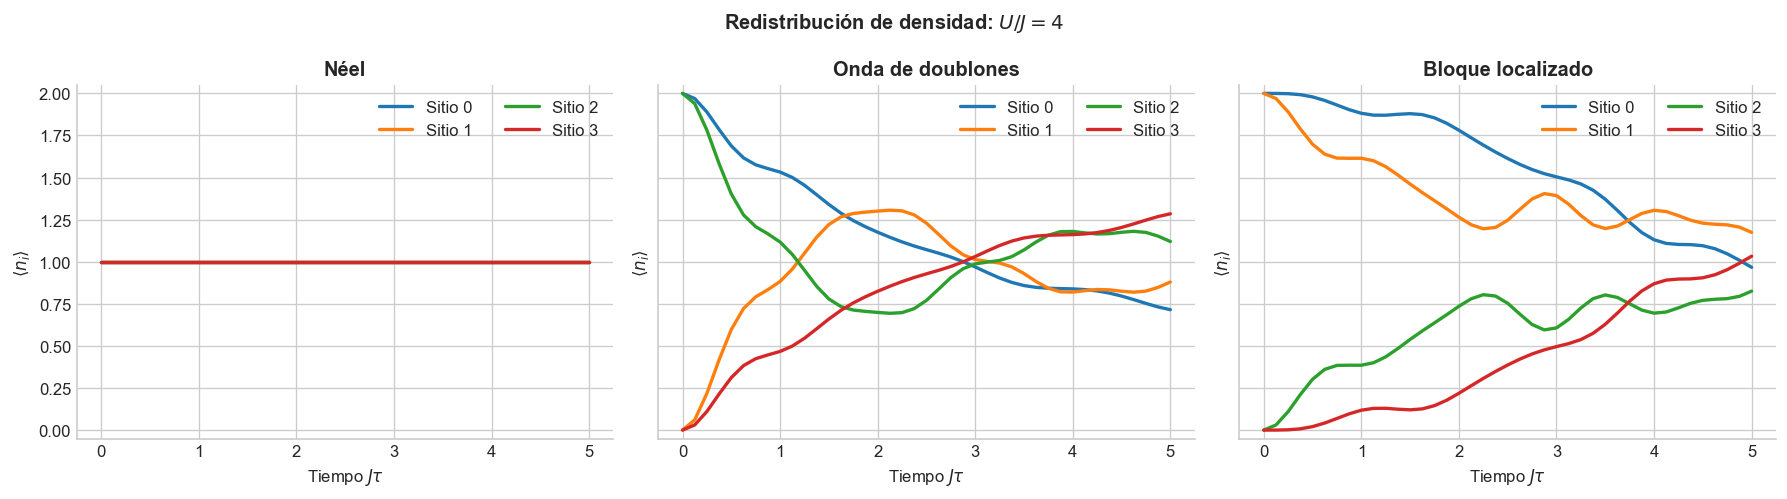

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
for ax, (nombre, (densidad, _, _)) in zip(axes, resultados_iniciales.items()):
    graficar_densidades(tiempos, densidad, nombre, ax=ax)
    ax.set_ylim(-0.05, 2.05)
fig.suptitle(rf"Redistribución de densidad: $U/J={U/J:g}$", fontweight="bold")
fig.tight_layout()
plt.show()

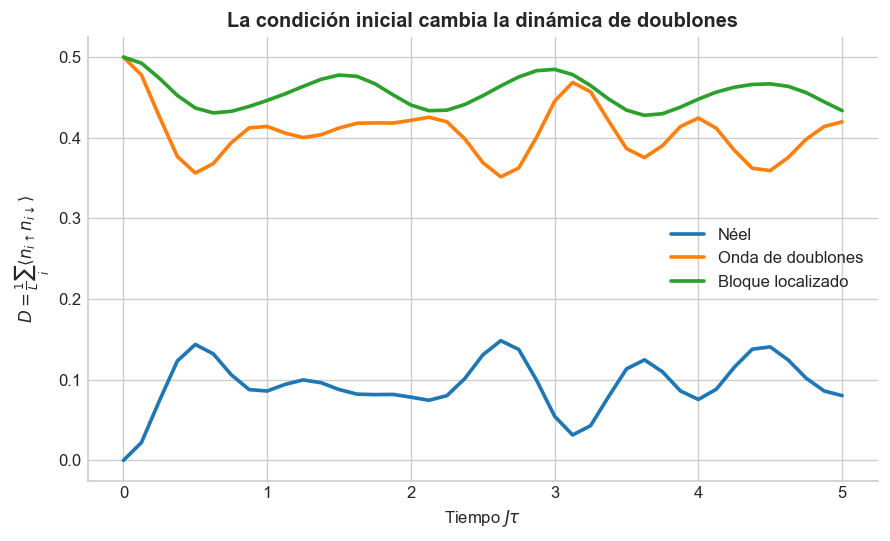

In [4]:
fig, ax = plt.subplots()
for nombre, (_, dobles, _) in resultados_iniciales.items():
    ax.plot(tiempos, dobles, lw=2.2, label=nombre)
ax.set(
    xlabel=r"Tiempo $J\tau$",
    ylabel=r"$D=\frac{1}{L}\sum_i\langle n_{i\uparrow}n_{i\downarrow}\rangle$",
    title="La condición inicial cambia la dinámica de doublones",
)
ax.legend()
plt.show()

La interacción no produce el mismo efecto sobre cualquier estado.
El estado de Néel comienza con $D=0$, mientras que la onda de doublones
comienza con $D=1/2$. Para $U/J$ grande, cambiar el número de doublones cuesta
energía y las oscilaciones quedan restringidas.

## 2. Barrido dinámico de la interacción

Mantenemos el estado de Néel y variamos $U$. Esta prueba muestra el bloqueo
dinámico de la doble ocupación; no debe confundirse todavía con una transición
del estado fundamental.

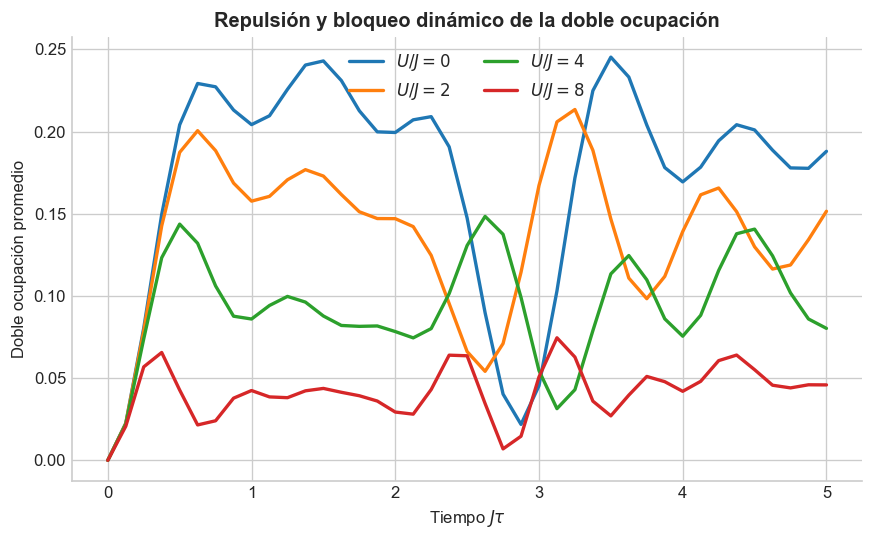

In [5]:
valores_U_dinamica = [0.0, 2.0, 4.0, 8.0]
dinamica_U = {}
for U_actual in valores_U_dinamica:
    dinamica_U[U_actual] = evolucion_FH(
        hop=J, U=U_actual, n_q=n_q, r=r,
        tiempos=tiempos, occupied_modes=condiciones["Néel"]
    )

fig, ax = plt.subplots()
for U_actual, (_, dobles, _) in dinamica_U.items():
    ax.plot(tiempos, dobles, lw=2, label=rf"$U/J={U_actual/J:g}$")
ax.set(
    xlabel=r"Tiempo $J\tau$",
    ylabel="Doble ocupación promedio",
    title="Repulsión y bloqueo dinámico de la doble ocupación",
)
ax.legend(ncol=2)
plt.show()

## 3. ¿Cuánto error introduce Trotter?

La diagonalización exacta permite evolucionar el mismo estado inicial sin
discretizar el tiempo. Comparamos ambas curvas y medimos el error cuadrático
medio de la doble ocupación. Al aumentar el número de pasos $r$, la
aproximación debe acercarse a la referencia.

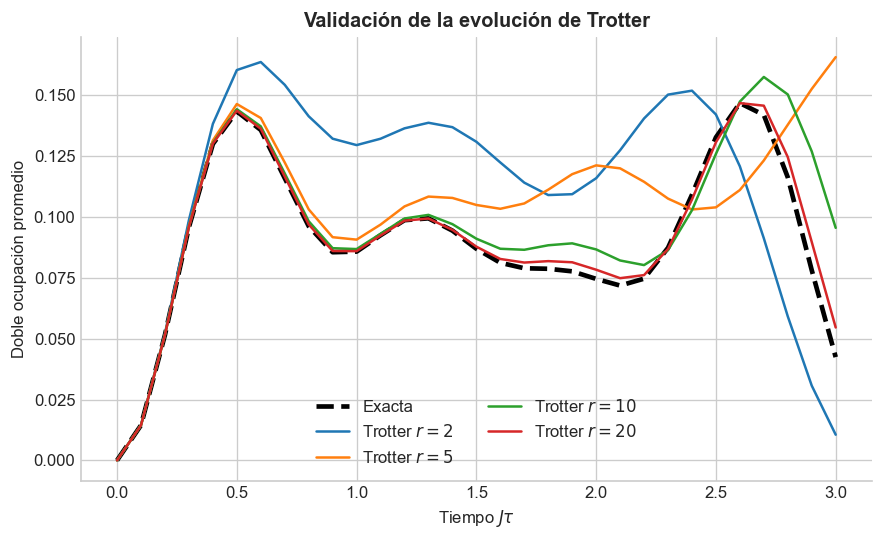

r= 2  RMSE=0.03881
r= 5  RMSE=0.03354
r=10  RMSE=0.01539
r=20  RMSE=0.00374


In [6]:
tiempos_validacion = np.linspace(0, 3, 31)
_, dobles_exactos, _ = evolucion_FH_exacta(
    hop=J, U=4.0, n_sites=n_sites,
    tiempos=tiempos_validacion,
    occupied_modes=condiciones["Néel"],
)

pasos_trotter = [2, 5, 10, 20]
errores = []
fig, ax = plt.subplots()
ax.plot(tiempos_validacion, dobles_exactos, "k--", lw=2.8, label="Exacta")
for pasos in pasos_trotter:
    _, dobles_trotter, _ = evolucion_FH(
        hop=J, U=4.0, n_q=n_q, r=pasos,
        tiempos=tiempos_validacion,
        occupied_modes=condiciones["Néel"],
    )
    errores.append(np.sqrt(np.mean((dobles_trotter - dobles_exactos) ** 2)))
    ax.plot(tiempos_validacion, dobles_trotter, lw=1.5, label=rf"Trotter $r={pasos}$")
ax.set(
    xlabel=r"Tiempo $J\tau$",
    ylabel="Doble ocupación promedio",
    title="Validación de la evolución de Trotter",
)
ax.legend(ncol=2)
plt.show()

for pasos, error in zip(pasos_trotter, errores):
    print(f"r={pasos:2d}  RMSE={error:.5f}")

## 4. Estado fundamental y cruce hacia el régimen de Mott

Para estudiar fases necesitamos el estado fundamental, no solo la evolución de
un estado producto. En una cadena de cuatro sitios calculamos exactamente:

- **Doble ocupación $D$:** disminuye cuando localizar dos fermiones juntos es costoso.
- **Brecha de carga $\Delta_c=E_0(N+1)+E_0(N-1)-2E_0(N)$:** energía necesaria
  para añadir y quitar carga.
- **Factor de estructura de espín $S(\pi)$:** mide correlaciones
  antiferromagnéticas escalonadas.

En el modelo de Hubbard 1D a media ocupación, el límite termodinámico es aislante
de Mott para cualquier $U>0$. Con solo cuatro sitios no aparece una singularidad:
observamos un **cruce suave**, y la brecha en $U=0$ contiene también una
contribución de tamaño finito.

### Intuición del régimen de Mott

El hopping $J$ intenta deslocalizar las partículas, mientras que $U$ penaliza que dos ocupen el mismo sitio. Cuando $U/J$ crece, los fermiones se localizan: baja la doble ocupación, aumenta la brecha de carga y aparecen correlaciones antiferromagnéticas. En esta cadena finita el cambio es suave; una transición de fase verdadera se identifica en el límite de muchos sitios.

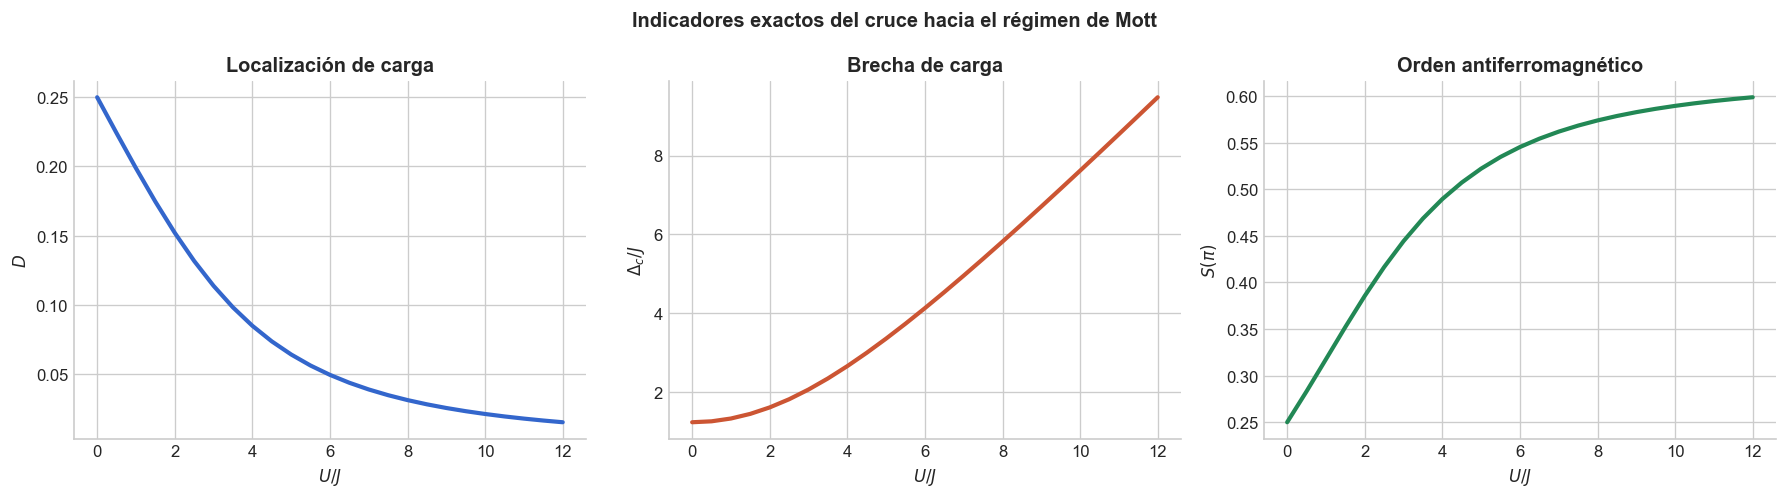

In [7]:
valores_U = np.linspace(0, 12, 25)
fase = barrido_estado_fundamental(valores_U, n_sites=n_sites, hop=J)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
axes[0].plot(fase["U"] / J, fase["doble_ocupacion"], color="#3366cc", lw=2.5)
axes[0].set(xlabel=r"$U/J$", ylabel=r"$D$", title="Localización de carga")

axes[1].plot(fase["U"] / J, fase["brecha_carga"] / J, color="#cc5533", lw=2.5)
axes[1].set(xlabel=r"$U/J$", ylabel=r"$\Delta_c/J$", title="Brecha de carga")

axes[2].plot(fase["U"] / J, fase["estructura_spin_pi"], color="#228855", lw=2.5)
axes[2].set(xlabel=r"$U/J$", ylabel=r"$S(\pi)$", title="Orden antiferromagnético")

fig.suptitle("Indicadores exactos del cruce hacia el régimen de Mott", fontweight="bold")
fig.tight_layout()
plt.show()

## 5. El parámetro relevante es $U/J$

Repetimos el cálculo para distintas amplitudes de hopping $J$. Si la física
depende del cociente $U/J$, las curvas deben colapsar al usar ese eje
adimensional. Esto también aclara que aumentar $J$ favorece la
deslocalización, mientras aumentar $U$ favorece la localización.

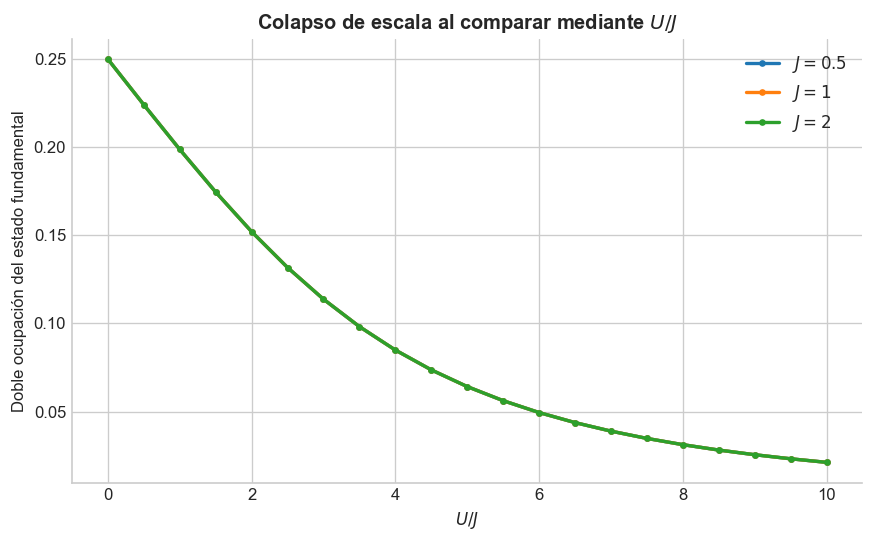

In [8]:
valores_J = [0.5, 1.0, 2.0]
razones = np.linspace(0, 10, 21)

fig, ax = plt.subplots()
for J_actual in valores_J:
    datos = barrido_estado_fundamental(
        razones * J_actual, n_sites=n_sites, hop=J_actual
    )
    ax.plot(
        datos["U"] / J_actual,
        datos["doble_ocupacion"],
        lw=2,
        marker="o",
        ms=3,
        label=rf"$J={J_actual:g}$",
    )
ax.set(
    xlabel=r"$U/J$",
    ylabel="Doble ocupación del estado fundamental",
    title=r"Colapso de escala al comparar mediante $U/J$",
)
ax.legend()
plt.show()

## 6. VQE con PennyLane

Como prueba variacional usamos $L=2$ sitios ($4$ qubits) a media ocupación. Cada capa aplica una rotación de tres ángulos por qubit, $$\mathrm{Rot}(\phi,\theta,\omega),$$ seguida de un anillo de CNOT. Una penalización mantiene el estado en el sector $N_\uparrow=N_\downarrow=1$. Para diez valores de $U/J$ comparamos la energía y la fidelidad $F=|\langle\psi_0|\psi_{VQE}\rangle|^2$ contra diagonalización exacta.

In [9]:
from IPython.display import Markdown, display

valores_U_vqe = np.linspace(0, 9, 10)
tabla_vqe, detalles_vqe = barrido_vqe_FH(
    valores_U_sobre_J=valores_U_vqe,
    hop=1.0,
    n_sites=2,
    n_layers=3,
    learning_rate=0.06,
    max_steps=250,
    seed=7,
)

lineas = [
    "| $U/J$ | $E_{VQE}$ | $E_{exacta}$ | Error | Fidelidad | Peso del sector |",
    "|---:|---:|---:|---:|---:|---:|",
]
for fila in tabla_vqe:
    lineas.append(
        f"| {fila['U/J']:.1f} | {fila['E_VQE']:.6f} | "
        f"{fila['E_exacta']:.6f} | {fila['error_E']:.2e} | "
        f"{fila['fidelidad']:.6f} | {fila['peso_sector']:.6f} |"
    )
display(Markdown("\n".join(lineas)))

lineas_observables = [
    "| $U/J$ | $D_{VQE}$ | $D_{exacta}$ | $S(\pi)_{VQE}$ | $S(\pi)_{exacta}$ | Error máximo de densidad |",
    "|---:|---:|---:|---:|---:|---:|",
]
for fila in tabla_vqe:
    lineas_observables.append(
        f"| {fila['U/J']:.1f} | {fila['D_VQE']:.6f} | "
        f"{fila['D_exacta']:.6f} | {fila['S_pi_VQE']:.6f} | "
        f"{fila['S_pi_exacta']:.6f} | {fila['error_densidad']:.2e} |"
    )
display(Markdown("### Observables del estado fundamental\n\n" + "\n".join(lineas_observables)))

| $U/J$ | $E_{VQE}$ | $E_{exacta}$ | Error | Fidelidad | Peso del sector |
|---:|---:|---:|---:|---:|---:|
| 0.0 | -1.999994 | -2.000000 | 5.93e-06 | 0.999996 | 0.999996 |
| 1.0 | -1.561552 | -1.561553 | 9.02e-07 | 0.999999 | 1.000000 |
| 2.0 | -1.235989 | -1.236068 | 7.87e-05 | 0.999961 | 0.999974 |
| 3.0 | -1.000000 | -1.000000 | 3.62e-10 | 1.000000 | 1.000000 |
| 4.0 | -0.828427 | -0.828427 | 5.38e-10 | 1.000000 | 1.000000 |
| 5.0 | -0.701562 | -0.701562 | 4.63e-10 | 1.000000 | 1.000000 |
| 6.0 | -0.605551 | -0.605551 | 3.97e-10 | 1.000000 | 1.000000 |
| 7.0 | -0.531129 | -0.531129 | 2.46e-10 | 1.000000 | 1.000000 |
| 8.0 | -0.472136 | -0.472136 | 3.08e-08 | 1.000000 | 1.000000 |
| 9.0 | -0.424429 | -0.424429 | 2.43e-10 | 1.000000 | 1.000000 |

### Observables del estado fundamental

| $U/J$ | $D_{VQE}$ | $D_{exacta}$ | $S(\pi)_{VQE}$ | $S(\pi)_{exacta}$ | Error máximo de densidad |
|---:|---:|---:|---:|---:|---:|
| 0.0 | 0.250002 | 0.250000 | 0.249998 | 0.250000 | 3.23e-06 |
| 1.0 | 0.189367 | 0.189366 | 0.310633 | 0.310634 | 3.81e-04 |
| 2.0 | 0.138200 | 0.138197 | 0.361797 | 0.361803 | 1.95e-04 |
| 3.0 | 0.100001 | 0.100000 | 0.399999 | 0.400000 | 5.16e-07 |
| 4.0 | 0.073222 | 0.073223 | 0.426778 | 0.426777 | 1.00e-06 |
| 5.0 | 0.054784 | 0.054783 | 0.445216 | 0.445217 | 6.99e-08 |
| 6.0 | 0.041988 | 0.041987 | 0.458012 | 0.458013 | 1.34e-09 |
| 7.0 | 0.032939 | 0.032939 | 0.467061 | 0.467061 | 4.55e-07 |
| 8.0 | 0.026394 | 0.026393 | 0.473606 | 0.473607 | 2.94e-06 |
| 9.0 | 0.021547 | 0.021547 | 0.478453 | 0.478453 | 6.73e-07 |

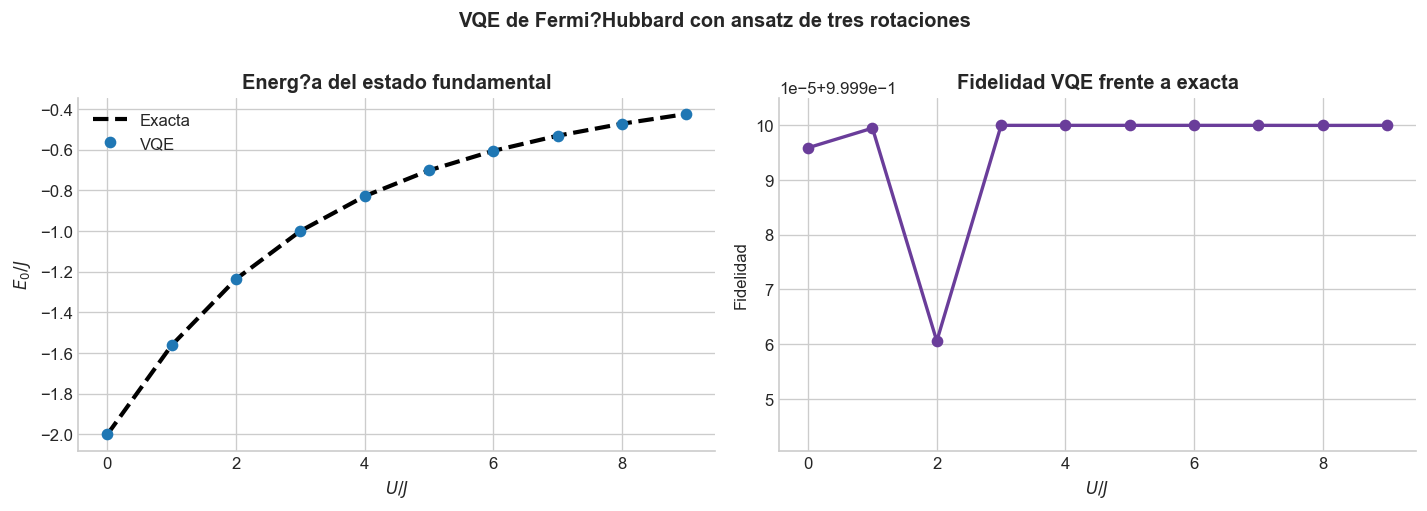

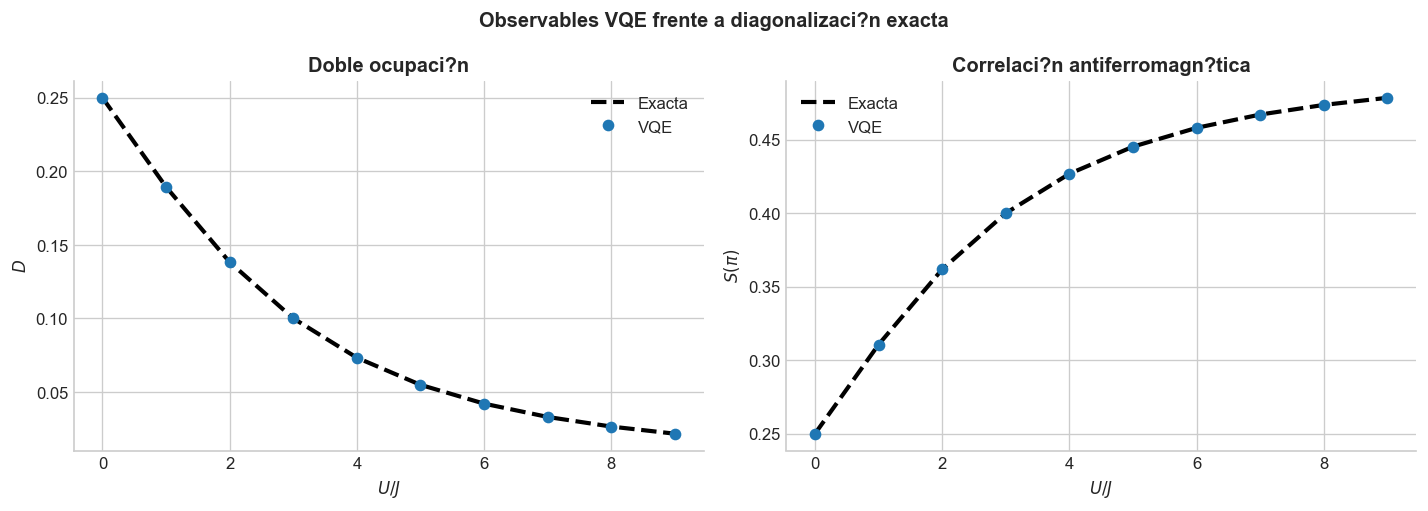

In [ ]:
razon_vqe = np.array([fila["U/J"] for fila in tabla_vqe])
energia_vqe = np.array([fila["E_VQE"] for fila in tabla_vqe])
energia_exacta = np.array([fila["E_exacta"] for fila in tabla_vqe])
fidelidad_vqe = np.array([fila["fidelidad"] for fila in tabla_vqe])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
axes[0].plot(razon_vqe, energia_exacta, "k--", lw=2.5, label="Exacta")
axes[0].plot(razon_vqe, energia_vqe, "o", ms=6, label="VQE")
axes[0].set(xlabel=r"$U/J$", ylabel=r"$E_0/J$", title="Energía del estado fundamental")
axes[0].legend()

axes[1].plot(razon_vqe, fidelidad_vqe, "o-", color="#6a3d9a", lw=2)
axes[1].set(xlabel=r"$U/J$", ylabel="Fidelidad", title="Fidelidad VQE frente a exacta")
axes[1].set_ylim(max(0.9999, fidelidad_vqe.min() - 2e-5), 1.000005)
fig.suptitle("VQE de Fermi–Hubbard con ansatz de tres rotaciones", fontweight="bold")
fig.tight_layout()
plt.show()

D_vqe = np.array([fila["D_VQE"] for fila in tabla_vqe])
D_exacta = np.array([fila["D_exacta"] for fila in tabla_vqe])
S_vqe = np.array([fila["S_pi_VQE"] for fila in tabla_vqe])
S_exacta = np.array([fila["S_pi_exacta"] for fila in tabla_vqe])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
axes[0].plot(razon_vqe, D_exacta, "k--", lw=2.5, label="Exacta")
axes[0].plot(razon_vqe, D_vqe, "o", ms=6, label="VQE")
axes[0].set(xlabel=r"$U/J$", ylabel=r"$D$", title="Doble ocupación")
axes[0].legend()

axes[1].plot(razon_vqe, S_exacta, "k--", lw=2.5, label="Exacta")
axes[1].plot(razon_vqe, S_vqe, "o", ms=6, label="VQE")
axes[1].set(xlabel=r"$U/J$", ylabel=r"$S(\pi)$", title="Correlación antiferromagnetica")
axes[1].legend()
fig.suptitle("Observables VQE frente a diagonalización exacta", fontweight="bold")
fig.tight_layout()
plt.show()

La fidelidad cercana a $1$ muestra que el ansatz reproduce el estado fundamental exacto en todo el barrido. El peso del sector también cercano a $1$ verifica que la penalización evita soluciones con un número incorrecto de partículas. La brecha de carga no se obtiene de un solo estado: requiere las energías de los sectores $N-1$, $N$ y $N+1$; por eso se conserva como referencia de diagonalización exacta.

## Conclusiones

1. La condición inicial controla qué procesos se ven en la dinámica: transporte,
   creación de doublones o relajación de una acumulación local.
2. Aumentar $U/J$ suprime la doble ocupación y frena las fluctuaciones de carga.
3. La diagonalización exacta confirma simultáneamente menor doble ocupación,
   mayor brecha de carga y correlaciones antiferromagnéticas más fuertes.
4. Para $L=4$ hablamos de un cruce de régimen, no de una transición crítica
   nítida. Identificar una transición termodinámica exigiría escalar $L$ y
   extrapolar observables.
5. La comparación exacta permite elegir $r$ de forma cuantitativa antes de
   ejecutar circuitos más costosos.